# REVISÃO GLOBAL (1º BIMESTRE)
**O Caso TechMarket: Do Caos à Inteligência Artificial**

**A Missão:** Você foi contratado como Cientista de Dados Sênior do e-commerce *TechMarket*. A empresa possui um banco de dados sujo e precisa que você passe por todo o ciclo de vida dos dados: desde adequação à LGPD, extração de relatórios descritivos, validação de um Teste A/B da nova interface, até a criação de um algoritmo preditivo.

---
### FASE 0: O Setup (Criação do Universo)

In [ ]:
# RODAR ESTA CÉLULA PARA INICIALIZAR O AMBIENTE (CÓDIGO FORNECIDO)


# ============================================================
# IMPORTANDO AS BIBLIOTECAS
# ============================================================

# Pandas → usado para trabalhar com tabelas e DataFrames.
import pandas as pd

# NumPy → usado para cálculos numéricos e geração de dados.
import numpy as np

# Seaborn → usado para criar gráficos estatísticos.
import seaborn as sns

# Matplotlib → usado para criar e personalizar gráficos.
import matplotlib.pyplot as plt

# SciPy → biblioteca usada para estatística e testes estatísticos.
from scipy import stats

# Importa o modelo de Regressão Linear.
from sklearn.linear_model import LinearRegression

# Importa métricas para avaliar modelos de regressão.
#
# root_mean_squared_error → calcula o RMSE,
# uma medida do erro médio das previsões.
#
# r2_score → calcula o R²,
# que indica quanto da variação dos dados é explicada pelo modelo.
from sklearn.metrics import root_mean_squared_error, r2_score


# Define um estilo visual para os gráficos do Seaborn.
sns.set_theme(style="whitegrid")


# ============================================================
# GERANDO A BASE SINTÉTICA DA TECHMARKET
# ============================================================

# Define uma semente para a aleatoriedade.
#
# Com seed(42), os mesmos valores aleatórios serão gerados
# toda vez que o código for executado.
np.random.seed(42)


# Define a quantidade de clientes da base.
n_clientes = 1000


# ============================================================
# GERANDO A IDADE DOS CLIENTES
# ============================================================

# Gera 1000 idades aleatórias entre 18 e 64 anos.
#
# np.random.randint(18, 65, 1000)
# → 18 é incluído
# → 65 não é incluído
# → portanto, valores de 18 até 64.
idades = np.random.randint(18, 65, n_clientes)


# ============================================================
# GERANDO OS E-MAILS
# ============================================================

# Cria uma lista com 1000 e-mails fictícios.
#
# f"cliente_{i}@email.com"
# → o valor de i muda a cada repetição.
#
# Resultado:
# cliente_0@email.com
# cliente_1@email.com
# cliente_2@email.com
# ...
emails = [f"cliente_{i}@email.com" for i in range(n_clientes)]


# ============================================================
# GERANDO AS REGIÕES
# ============================================================

# Escolhe aleatoriamente uma região para cada cliente.
#
# Regiões possíveis:
# Sul
# Sudeste
# Nordeste
#
# p=[0.2, 0.5, 0.3]
# → define a probabilidade de cada região:
#
# Sul      → 20%
# Sudeste  → 50%
# Nordeste → 30%
regioes = np.random.choice(
    ['Sul', 'Sudeste', 'Nordeste'],
    n_clientes,
    p=[0.2, 0.5, 0.3]
)


# ============================================================
# GERANDO AS VERSÕES DO SITE
# ============================================================

# Escolhe aleatoriamente a versão A ou B para cada cliente.
#
# Cada cliente será associado a uma das duas versões.
versoes = np.random.choice(
    ['A', 'B'],
    n_clientes
)


# ============================================================
# GERANDO O TEMPO DE TELA
# ============================================================

# Gera 500 tempos de tela para usuários da versão A.
#
# Distribuição normal:
# média = 15 minutos
# desvio padrão = 5 minutos
# quantidade = 500
tempo_A = np.random.normal(15, 5, 500)


# Gera 500 tempos de tela para usuários da versão B.
#
# média = 17 minutos
# desvio padrão = 5 minutos
# quantidade = 500
tempo_B = np.random.normal(17, 5, 500)


# Junta os 500 valores da versão A com os 500 valores
# da versão B.
#
# Resultado:
# 1000 valores no total.
tempo_tela = np.concatenate([tempo_A, tempo_B])


# ============================================================
# EMBARALHANDO OS DADOS
# ============================================================

# Embaralha os 1000 valores de tempo de tela.
#
# Isso evita que os primeiros 500 valores sejam sempre da
# versão A e os últimos 500 sejam sempre da versão B.
np.random.shuffle(tempo_tela)


# ============================================================
# GERANDO O GASTO DOS CLIENTES
# ============================================================

# Cria o gasto de cada cliente utilizando uma fórmula.
#
# tempo_tela * 25
# → quanto maior o tempo no site, maior tende a ser o gasto.
#
# + 150
# → adiciona um valor base de R$150.
#
# + np.random.normal(0, 100, n_clientes)
# → adiciona um ruído aleatório:
#    média = 0
#    desvio padrão = 100
#    quantidade = 1000
#
# Portanto:
#
# Gasto = (Tempo de Tela × 25) + 150 + Ruído
gasto = (
    (tempo_tela * 25)
    + 150
    + np.random.normal(0, 100, n_clientes)
)


# ============================================================
# CRIANDO ANOMALIAS / OUTLIERS
# ============================================================

# Substitui o gasto do cliente de índice 10 por R$9.500.
#
# Esse valor é muito maior que os gastos normais
# e representa um OUTLIER.
gasto[10] = 9500


# Substitui o gasto do cliente de índice 50 por R$8.800.
#
# Também é um OUTLIER.
gasto[50] = 8800


# ============================================================
# CRIANDO O DATAFRAME
# ============================================================

# Cria um DataFrame contendo todas as informações geradas.
df = pd.DataFrame({
    
    # Idade do cliente.
    'Idade': idades,
    
    # E-mail fictício do cliente.
    'Email': emails,
    
    # Região do cliente.
    'Regiao': regioes,
    
    # Versão do site utilizada pelo cliente.
    'Versao_Site': versoes,
    
    # Tempo que o cliente permaneceu na tela/site.
    'Tempo_Tela_Min': np.abs(tempo_tela),
    
    # Valor gasto pelo cliente no site.
    'Gasto_Site_R$': np.abs(gasto)
})


# ============================================================
# FINALIZAÇÃO
# ============================================================

# Exibe uma mensagem confirmando que a base foi criada.
print("Base gerada com sucesso! Bem-vindo à TechMarket.")


# Mostra as 5 primeiras linhas do DataFrame.
#
# head() → retorna as primeiras 5 linhas.
df.head()

Base gerada com sucesso! Bem-vindo à TechMarket.


,Idade,Email,Regiao,Versao_Site,Tempo_Tela_Min,Gasto_Site_R$
0,56,cliente_0@email.com,Sudeste,B,18.352403,473.994720
1,46,cliente_1@email.com,Nordeste,B,17.189689,671.998581
2,32,cliente_2@email.com,Sudeste,A,23.876554,810.550434
3,60,cliente_3@email.com,Sudeste,A,19.503329,604.851196
4,25,cliente_4@email.com,Nordeste,B,21.450992,571.057863


### FASE 1: O Alerta Jurídico (LGPD)
A base contém Informações Pessoalmente Identificáveis (PII). A equipe de Data Science não precisa expor a identidade dos usuários para prever faturamento.

In [12]:
# MISSÃO 1:
# 1. Exclua a coluna que expõe a identidade do cliente usando a função apropriada do Pandas.
# 2. Salve o resultado numa variável chamada 'df_seguro'.
# 3. Mostre as primeiras linhas da nova base para confirmar.

# SEU CÓDIGO AQUI:
df_seguro = df.drop(columns=['Email'])
df_seguro.head()


,Idade,Regiao,Versao_Site,Tempo_Tela_Min,Gasto_Site_R$
0,56,Sudeste,B,18.352403,473.994720
1,46,Nordeste,B,17.189689,671.998581
2,32,Sudeste,A,23.876554,810.550434
3,60,Sudeste,A,19.503329,604.851196
4,25,Nordeste,B,21.450992,571.057863


### FASE 2: O Raio-X Estatístico (Diagnosticando o Passado)
A diretoria de vendas precisa de um retrato rápido de quem é o cliente atual da TechMarket.

In [ ]:
# MISSÃO 2:
# 1. Qual é a Região que mais acessa o site? Encontre e imprima a MODA.
# 2. Qual é a MÉDIA da coluna 'Gasto_Site_R$'?
# 3. Qual é a MEDIANA da coluna 'Gasto_Site_R$'?
# 4. Comente (#) logo abaixo: Comparando a média e a mediana,
#    a sua base parece ter Outliers? Por quê?


# ============================================================
# 1. MODA DA REGIÃO
# ============================================================

# .mode() encontra o valor que mais se repete na coluna.
#
# [0] pega o primeiro resultado retornado pela moda.
moda_regiao = df_seguro['Regiao'].mode()[0]

# Imprime a região que aparece com maior frequência.
print(f"Região que mais acessa o site: {moda_regiao}")


# ============================================================
# 2. MÉDIA DO GASTO
# ============================================================

# .mean() calcula a média aritmética dos valores da coluna.
#
# A média é calculada somando todos os gastos
# e dividindo pela quantidade de clientes.
media_gasto = df_seguro['Gasto_Site_R$'].mean()

# :.2f → mostra o valor com 2 casas decimais.
print(f"Média do gasto: R$ {media_gasto:.2f}")


# ============================================================
# 3. MEDIANA DO GASTO
# ============================================================

# .median() calcula a mediana.
#
# A mediana é o valor que fica no meio dos dados
# quando eles estão ordenados.
mediana_gasto = df_seguro['Gasto_Site_R$'].median()

# :.2f → mostra o valor com 2 casas decimais.
print(f"Mediana do gasto: R$ {mediana_gasto:.2f}")


# ============================================================
# 4. INTERPRETAÇÃO
# ============================================================

# A média é maior que a mediana, indicando que existem
# valores muito altos influenciando a média.
#
# Isso indica uma possível assimetria à direita na distribuição.
#
# Essa diferença é compatível com a presença de outliers
# na base, como os gastos de R$ 8.800 e R$ 9.500
# que foram inseridos anteriormente.
#
# A mediana sofre menos influência de valores extremos,
# enquanto a média é mais sensível a eles.

região que mais acessa o site: Sudeste
Média do gasto: R$  569.89
Mediana do gasto: R$  555.59


### FASE 3: Tradução Visual
A diretoria não lê terminais de código. Precisamos provar os números com gráficos.

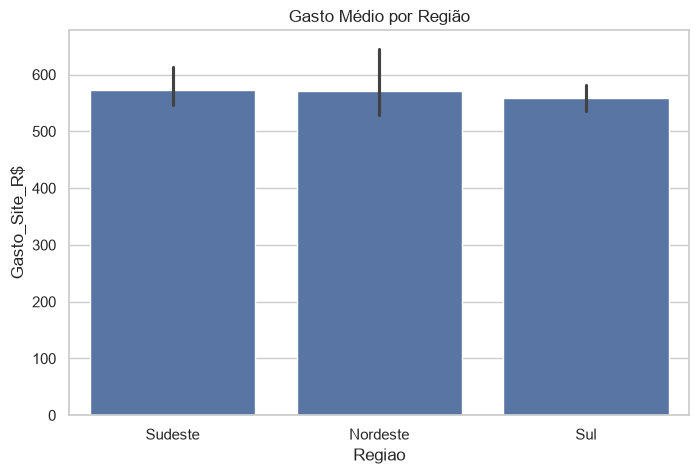

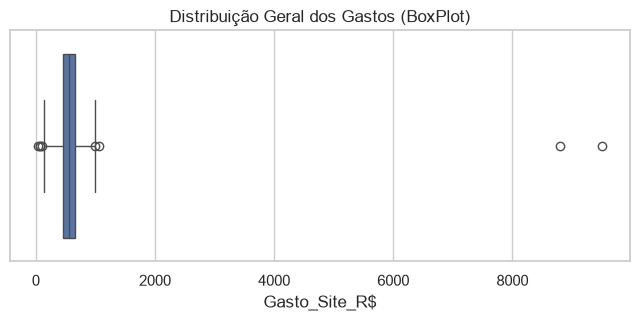

In [ ]:
# MISSÃO 3:
# Usando o Seaborn (sns):
# 1. Plote um gráfico de Barras (barplot) mostrando o Gasto (y)
#    separado por Regiao (x).
# 2. Plote um Gráfico de Caixa (boxplot) do Gasto geral do site.
# 3. Comente (#): O boxplot ajudou a confirmar a sua desconfiança
#    da Fase 2 sobre os Outliers?


# ============================================================
# 1. GRÁFICO DE BARRAS — GASTO POR REGIÃO
# ============================================================

# Define o tamanho da figura:
# largura = 8
# altura = 5
plt.figure(figsize=(8, 5))


# Cria um gráfico de barras.
#
# data=df_seguro → utiliza o DataFrame.
#
# x='Regiao'
# → coloca as regiões no eixo X.
#
# y='Gasto_Site_R$'
# → coloca o gasto no eixo Y.
#
# O barplot mostra o GASTO MÉDIO para cada região.
sns.barplot(
    data=df_seguro,
    x='Regiao',
    y='Gasto_Site_R$'
)


# Define o título do gráfico.
plt.title('Gasto Médio por Região')


# Exibe o gráfico.
plt.show()


# ============================================================
# 2. BOXPLOT — DISTRIBUIÇÃO DOS GASTOS
# ============================================================

# Cria uma nova figura.
#
# largura = 8
# altura = 3
plt.figure(figsize=(8, 3))


# Cria um gráfico de caixa (boxplot).
#
# x='Gasto_Site_R$'
# → coloca todos os gastos no eixo X.
#
# O boxplot permite visualizar:
# - mediana
# - quartis
# - dispersão dos dados
# - possíveis outliers
sns.boxplot(
    data=df_seguro,
    x='Gasto_Site_R$'
)


# Define o título do gráfico.
plt.title('Distribuição Geral dos Gastos (BoxPlot)')


# Exibe o gráfico.
plt.show()


# ============================================================
# 3. INTERPRETAÇÃO
# ============================================================

# Sim. O boxplot confirma a suspeita da Fase 2 sobre
# a existência de outliers.
#
# A caixa representa a região onde está concentrada
# a maior parte dos gastos dos clientes.
#
# Os pontos isolados e muito distantes da caixa,
# próximos de R$ 8.000 e R$ 9.000, representam
# possíveis OUTLIERS.
#
# Esses valores extremos ajudam a explicar por que a
# média ficou maior que a mediana.
#
# Portanto, o boxplot fornece uma evidência visual
# da presença de valores extremos na base.

### FASE 4: O Tribunal da Ciência (Teste A/B)
A equipe de UX lançou a Versão B do site (com botões laranjas) apostando que ela prenderia o cliente por mais tempo na tela do que a Versão A (Verde).

- **H0 (Nula):** O tempo de tela é igual. O acaso manda.
- **H1 (Alternativa):** O tempo de tela da versão B é matematicamente distinto.

In [ ]:
# MISSÃO 4:
# 1. Separar o 'Tempo_Tela_Min' dos usuários da Versão A.
# 2. Separar o 'Tempo_Tela_Min' dos usuários da Versão B.
# 3. Usar o teste t de Student para comparar os dois grupos
#    e obter o p-valor.
# 4. Comparar o p-valor com alfa = 0.05.


# ============================================================
# 1. TEMPO DE TELA — VERSÃO A
# ============================================================

# Filtra apenas os clientes que acessaram a Versão A.
#
# df_seguro['Versao_Site'] == 'A'
# → cria uma condição booleana.
#
# Depois selecionamos somente a coluna 'Tempo_Tela_Min'.
tempo_A = df_seguro[
    df_seguro['Versao_Site'] == 'A'
]['Tempo_Tela_Min']


# ============================================================
# 2. TEMPO DE TELA — VERSÃO B
# ============================================================

# Faz o mesmo processo, mas selecionando apenas
# os clientes que acessaram a Versão B.
tempo_B = df_seguro[
    df_seguro['Versao_Site'] == 'B'
]['Tempo_Tela_Min']


# ============================================================
# 3. TESTE T DE STUDENT
# ============================================================

# Compara as médias dos grupos A e B.
#
# stats.ttest_ind()
# → realiza um teste t para duas amostras independentes.
#
# O resultado contém, entre outras informações:
# - statistic → estatística do teste
# - pvalue → p-valor
resultado_teste = stats.ttest_ind(
    tempo_A,
    tempo_B
)


# Extrai somente o p-valor do resultado.
p_valor = resultado_teste.pvalue


# Mostra o p-valor com 5 casas decimais.
print(
    f"O p-valor calculado pelo SciPy foi: {p_valor:.5f}"
)


# ============================================================
# 4. DECISÃO COM ALFA = 0.05
# ============================================================

# Define o nível de significância.
#
# Alfa = 0.05 significa que estamos utilizando
# um nível de significância de 5%.
alfa = 0.05


# Verifica se o p-valor é menor que alfa.
#
# Se p < 0.05:
# → rejeitamos a hipótese nula.
# → existe evidência estatística de diferença entre os grupos.
#
# Se p >= 0.05:
# → não rejeitamos a hipótese nula.
# → não temos evidência estatística suficiente de diferença.
if p_valor < alfa:
    print(
        "A diferença é estatisticamente significativa! "
        "Há evidência de diferença entre as versões."
    )
else:
    print(
        "A diferença não é estatisticamente significativa; "
        "não há evidência suficiente de diferença entre as versões."
    )


# ============================================================
# MACETE PARA A PROVA
# ============================================================

# p < 0.05 → diferença estatisticamente significativa
#
# p >= 0.05 → diferença não estatisticamente significativa
#
# IMPORTANTE:
# "Não significativo" não significa que as versões são
# exatamente iguais. Significa que o teste não encontrou
# evidência suficiente para afirmar que existe diferença.

O p-valor calculado pelo SciPy foi: 0.98697
A diferença não é significativa, apenas ruído (acaso). Mantenha a Versão A.


### FASE 5: Correlação e o Motor de Previsão
Será que o Tempo de Tela puxa o Faturamento? Vamos comprovar e construir o nosso modelo.

A Correlação de Pearson é: 0.31


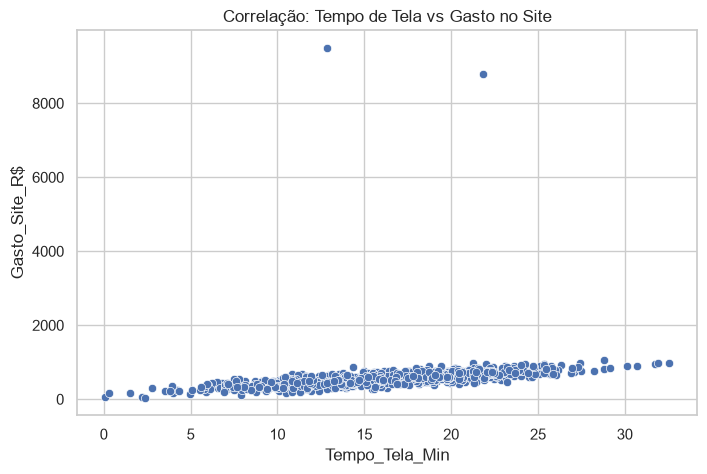

In [ ]:
# MISSÃO 5.1 (A Prova do Crime):
# 1. Calcular a Correlação de Pearson entre Tempo_Tela e Gasto_Site.
# 2. Desenhar um Scatterplot dessas duas colunas.


# ============================================================
# 1. CORRELAÇÃO DE PEARSON
# ============================================================

# Calcula a correlação de Pearson entre:
# 'Tempo_Tela_Min' → tempo que o cliente ficou no site
# 'Gasto_Site_R$'  → quanto o cliente gastou
#
# .corr()
# → calcula a correlação entre duas séries.
#
# Por padrão, o método utilizado é Pearson.
correlacao = df_seguro['Tempo_Tela_Min'].corr(
    df_seguro['Gasto_Site_R$']
)


# Mostra o valor da correlação.
#
# :.2f
# → mostra o resultado com 2 casas decimais.
print(f"A Correlação de Pearson é: {correlacao:.2f}")


# ============================================================
# 2. SCATTERPLOT
# ============================================================

# Define o tamanho da figura:
# largura = 8
# altura = 5
plt.figure(figsize=(8, 5))


# Cria um gráfico de dispersão (nuvem de pontos).
#
# data=df_seguro
# → utiliza o DataFrame.
#
# x='Tempo_Tela_Min'
# → coloca o tempo de tela no eixo X.
#
# y='Gasto_Site_R$'
# → coloca o gasto no eixo Y.
#
# Cada ponto representa um cliente.
sns.scatterplot(
    data=df_seguro,
    x='Tempo_Tela_Min',
    y='Gasto_Site_R$'
)


# Define o título do gráfico.
plt.title('Correlação: Tempo de Tela vs Gasto no Site')


# Exibe o gráfico.
plt.show()


# ============================================================
# INTERPRETAÇÃO
# ============================================================

# A correlação de Pearson indica a força e a direção
# da relação LINEAR entre o tempo de tela e o gasto.
#
# Correlação positiva:
# → clientes que passam mais tempo no site tendem
#   a gastar mais.
#
# Quanto mais próximo de +1:
# → mais forte é a relação positiva.
#
# Quanto mais próximo de 0:
# → mais fraca é a relação linear.
#
# IMPORTANTE:
# Correlação não significa causalidade.

In [ ]:
# MISSÃO 5.2 (O TREINAMENTO E AS MÉTRICAS):
# IMPORTANTE: remover os dois outliers de gasto muito alto
# para evitar que eles distorçam o treinamento do modelo.


# ============================================================
# 1. REMOVENDO OS OUTLIERS
# ============================================================

# Mantém somente os clientes que gastaram menos de R$ 8.000.
#
# Os valores de R$ 8.800 e R$ 9.500 são removidos.
#
# Isso cria uma nova base chamada 'df_limpo',
# sem alterar o DataFrame original.
df_limpo = df_seguro[df_seguro['Gasto_Site_R$'] < 8000]


# ============================================================
# 2. SEPARANDO X E Y
# ============================================================

# X = variável de entrada (independente).
#
# Aqui utilizamos apenas o 'Tempo_Tela_Min'
# para tentar prever o gasto.
#
# Os dois colchetes [[ ]] mantêm X como um DataFrame 2D,
# que é o formato esperado pelo Scikit-learn.
X = df_limpo[['Tempo_Tela_Min']]


# y = variável que queremos prever (dependente).
#
# Aqui queremos prever o 'Gasto_Site_R$'.
#
# Um único colchete [ ] retorna uma Series 1D.
y = df_limpo['Gasto_Site_R$']


# ============================================================
# 3. CRIANDO E TREINANDO O MODELO
# ============================================================

# Cria um modelo de Regressão Linear.
#
# O modelo tentará encontrar a melhor reta que relaciona
# o tempo de tela com o gasto.
modelo = LinearRegression()


# Treina o modelo utilizando:
#
# X → variável de entrada (Tempo_Tela_Min)
# y → variável que queremos prever (Gasto_Site_R$)
#
# O modelo aprende o peso (coef_) e o viés (intercept_).
modelo.fit(X, y)


# ============================================================
# 4. GERANDO AS PREVISÕES
# ============================================================

# Utiliza o modelo treinado para prever o gasto
# dos clientes presentes em X.
#
# O resultado é armazenado em 'previsoes'.
previsoes = modelo.predict(X)


# ============================================================
# 5. CALCULANDO AS MÉTRICAS
# ============================================================

# Calcula o R² (R2 Score).
#
# O R² indica quanto da variação do gasto é explicada
# pelo modelo utilizando o tempo de tela.
#
# Quanto mais próximo de 1, maior a proporção da
# variação explicada pelo modelo.
r2 = r2_score(y, previsoes)


# Calcula o RMSE (Root Mean Squared Error).
#
# O RMSE mede o tamanho médio dos erros das previsões,
# na mesma unidade da variável 'Gasto_Site_R$'.
#
# Quanto menor o RMSE, menor tende a ser o erro das previsões.
rmse = root_mean_squared_error(y, previsoes)


# ============================================================
# 6. MOSTRANDO AS MÉTRICAS
# ============================================================

print("Métricas do Modelo:")

# Mostra o R² com 4 casas decimais.
print(f"R² Score: {r2:.4f}")

# Mostra o RMSE com 2 casas decimais.
print(f"RMSE (Margem de Erro Média): R$ {rmse:.2f}\n")


# ============================================================
# 7. EXTRAINDO PESO E VIÉS
# ============================================================

# modelo.coef_ contém o peso (coeficiente) aprendido
# pelo modelo.
#
# Como temos apenas uma variável de entrada,
# [0] pega o primeiro coeficiente.
peso = modelo.coef_[0]


# modelo.intercept_ representa o viés/intercepto.
#
# É o valor estimado de Y quando X = 0.
vies = modelo.intercept_


# ============================================================
# 8. MOSTRANDO A EQUAÇÃO DA REGRESSÃO
# ============================================================

# Mostra a equação que o modelo aprendeu.
#
# Fórmula geral da regressão linear:
#
# Y = (peso × X) + viés
#
# Neste caso:
#
# Gasto = (peso × minutos) + viés
print(
    f"A equação da IA é: "
    f"Gasto = ({peso:.2f} * Minutos) + {vies:.2f}"
)


# ============================================================
# RESUMO PARA A PROVA
# ============================================================

# X → entrada / variável independente
# y → saída / variável dependente
#
# fit() → TREINA o modelo
# predict() → FAZ previsões
#
# R² → mede quanto da variação é explicada pelo modelo
# RMSE → mede o tamanho dos erros das previsões
#
# coef_ → PESO da variável
# intercept_ → VIÉS / valor inicial
#
# Equação:
# Gasto = (peso × Tempo_Tela) + viés

Métricas do Modelo:
R² Score: 0.6247
RMSE (Margem de Erro Média): R$ 98.01

A equação da IA é: Gasto = (25.31 * Minutos) + 146.03


In [ ]:
# MISSÃO FINAL BOSS (O USO EM PRODUÇÃO):
# O Diretor de Marketing perguntou:
# "Se o cliente ficar exatamente 45 minutos no site,
# qual a previsão de dinheiro que ele vai deixar?
# E qual a nossa margem de erro financeira?"


# ============================================================
# 1. PREVISÃO PARA 45 MINUTOS
# ============================================================

# Usa o modelo treinado para fazer uma previsão.
#
# [[45]]
# → representa uma entrada com:
#    1 cliente
#    1 variável (Tempo_Tela_Min)
#    valor = 45 minutos
#
# .predict()
# → faz a previsão utilizando o modelo treinado.
#
# [0]
# → pega o primeiro resultado da previsão.
previsao_45_min = modelo.predict([[45]])[0]


# ============================================================
# 2. CENÁRIO OTIMISTA
# ============================================================

# O teto é calculado somando o RMSE à previsão central.
#
# Previsão + RMSE
#
# O RMSE representa uma medida do tamanho típico dos erros
# do modelo, na mesma unidade do gasto (R$).
teto = previsao_45_min + rmse


# ============================================================
# 3. CENÁRIO PESSIMISTA
# ============================================================

# O piso é calculado subtraindo o RMSE da previsão central.
#
# Previsão - RMSE
piso = previsao_45_min - rmse


# ============================================================
# 4. EXIBINDO O RELATÓRIO
# ============================================================

# Imprime o título do relatório.
print("=== RELATÓRIO DE PREVISÃO DA TECHMARKET ===")


# Mostra o tempo utilizado para fazer a previsão.
print(f"Tempo de tela analisado: 45 minutos\n")


# Mostra a previsão central feita pelo modelo.
#
# :.2f
# → mostra o valor com duas casas decimais.
print(f"Previsão Exata Central: R$ {previsao_45_min:.2f}")


# Mostra o cenário otimista:
# previsão central + RMSE.
print(f"Cenário Otimista (Teto): R$ {teto:.2f}")


# Mostra o cenário pessimista:
# previsão central - RMSE.
print(f"Cenário Pessimista (Piso): R$ {piso:.2f}")


# ============================================================
# RESUMO PARA A PROVA
# ============================================================

# modelo.predict([[45]])
# → prevê o gasto para 45 minutos de tela.
#
# Teto = Previsão + RMSE
# → cenário otimista.
#
# Piso = Previsão - RMSE
# → cenário pessimista.
#
# RMSE
# → representa uma medida do erro típico das previsões,
#   na mesma unidade do gasto (R$).
#
# IMPORTANTE:
# O "teto" e o "piso" calculados dessa forma são uma
# faixa simples de referência usando ± RMSE.
# Eles não representam, por si só, um intervalo de
# confiança estatístico.

=== RELATÓRIO DE PREVISÃO DA TECHMARKET ===
Tempo de tela analisado: 45 minutos

Previsão Exata Central: R$ 1285.03
Cenário Otimista (Teto): R$ 1383.04
Cenário Pessimista (Piso): R$ 1187.02


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
